In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("default")
sns.set_theme()

In [4]:
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")

aum_history = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

monthly_sip_inflows = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

category_inflows = pd.read_csv("../data/processed/clean_category_inflows.csv")

industry_folio_counts = pd.read_csv("../data/processed/clean_industry_folio_count.csv")

portfolio_holdings = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

benchmark_indices = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

nav_history = pd.read_csv("../data/processed/clean_nav.csv")

investor_transc = pd.read_csv("../data/processed/clean_investor_transactions.csv")

scheme_performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

In [9]:
nav_history.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [11]:
nav_history['date'] = pd.to_datetime(nav_history['date'], format = "mixed")

In [15]:
code  = nav_history['amfi_code'].nunique()
print(code)

40


In [17]:
code2  = nav_history['amfi_code'].unique()
print(code2)

[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632
 118633 118634 118635 118636 119092 119093 119094 119095 119120 119551
 119552 119598 119599 120503 120504 120505 120506 120507 120841 120842
 120843 120844 125497 125498 148567 148568 148569 149322 149323 149324]


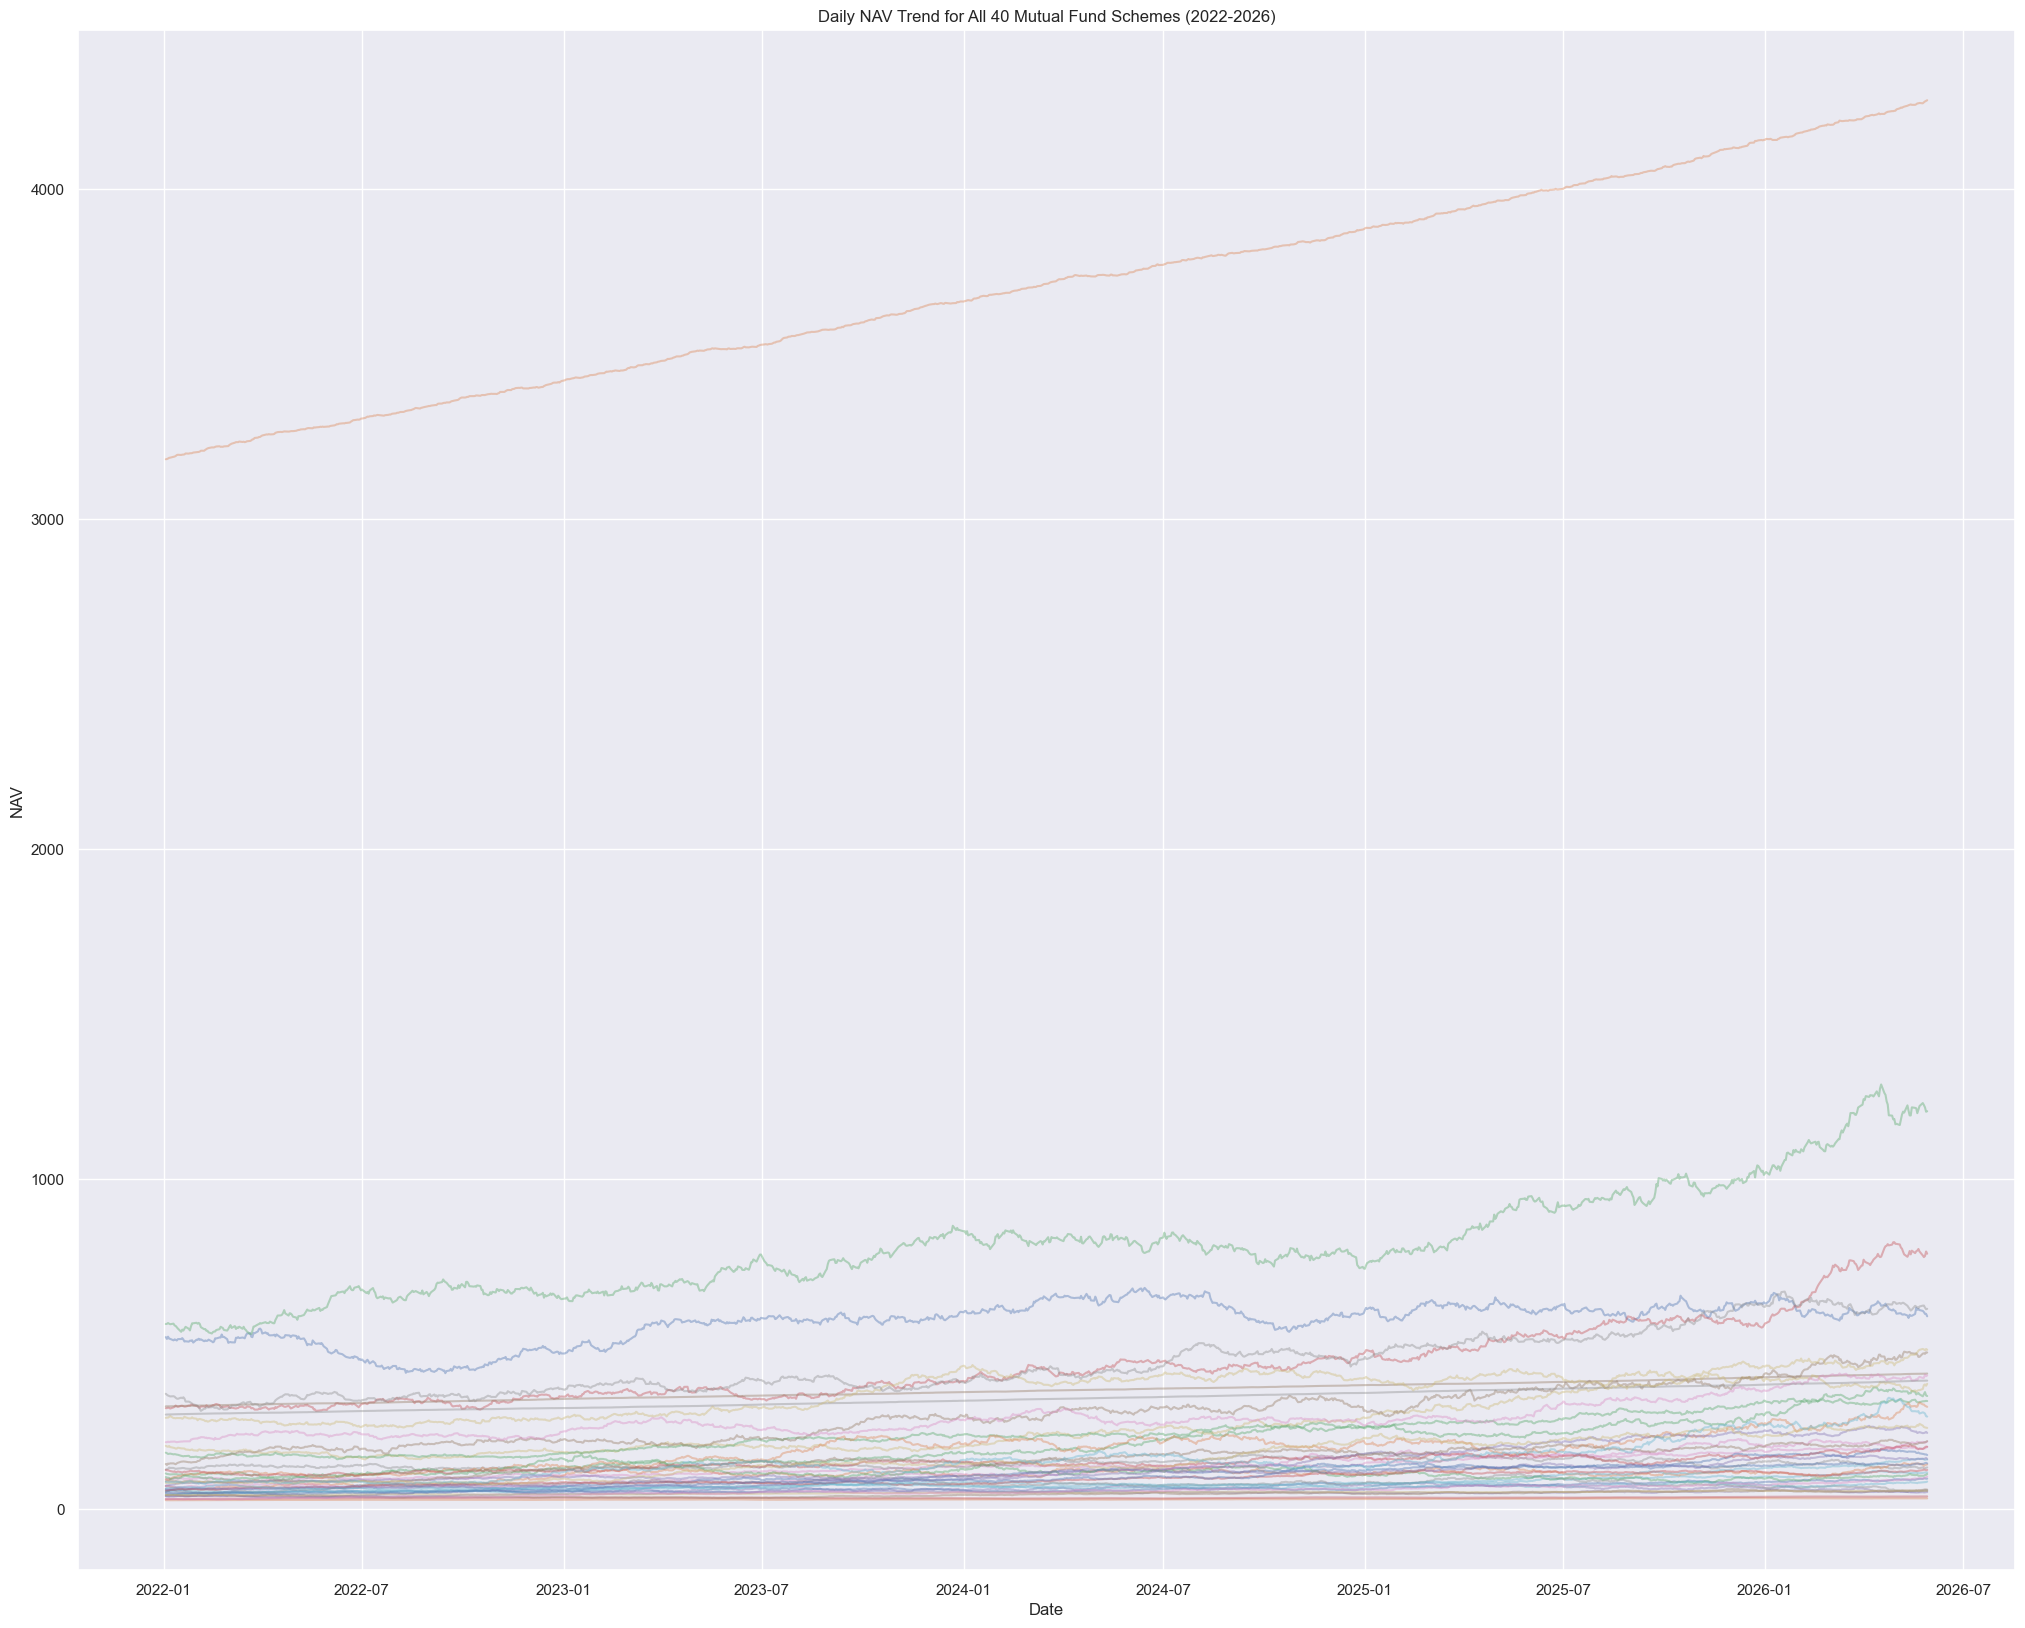

In [20]:
plt.figure(figsize=(25, 20))
for scheme in code2:
    temp = nav_history[nav_history['amfi_code'] == scheme]
    plt.plot(
        temp['date'],
        temp['nav'],
        alpha=0.4,
        label=scheme
    )
plt.xlabel("Date")
plt.ylabel("NAV")
plt.title("Daily NAV Trend for All 40 Mutual Fund Schemes (2022-2026)")
plt.grid(True)
plt.show()




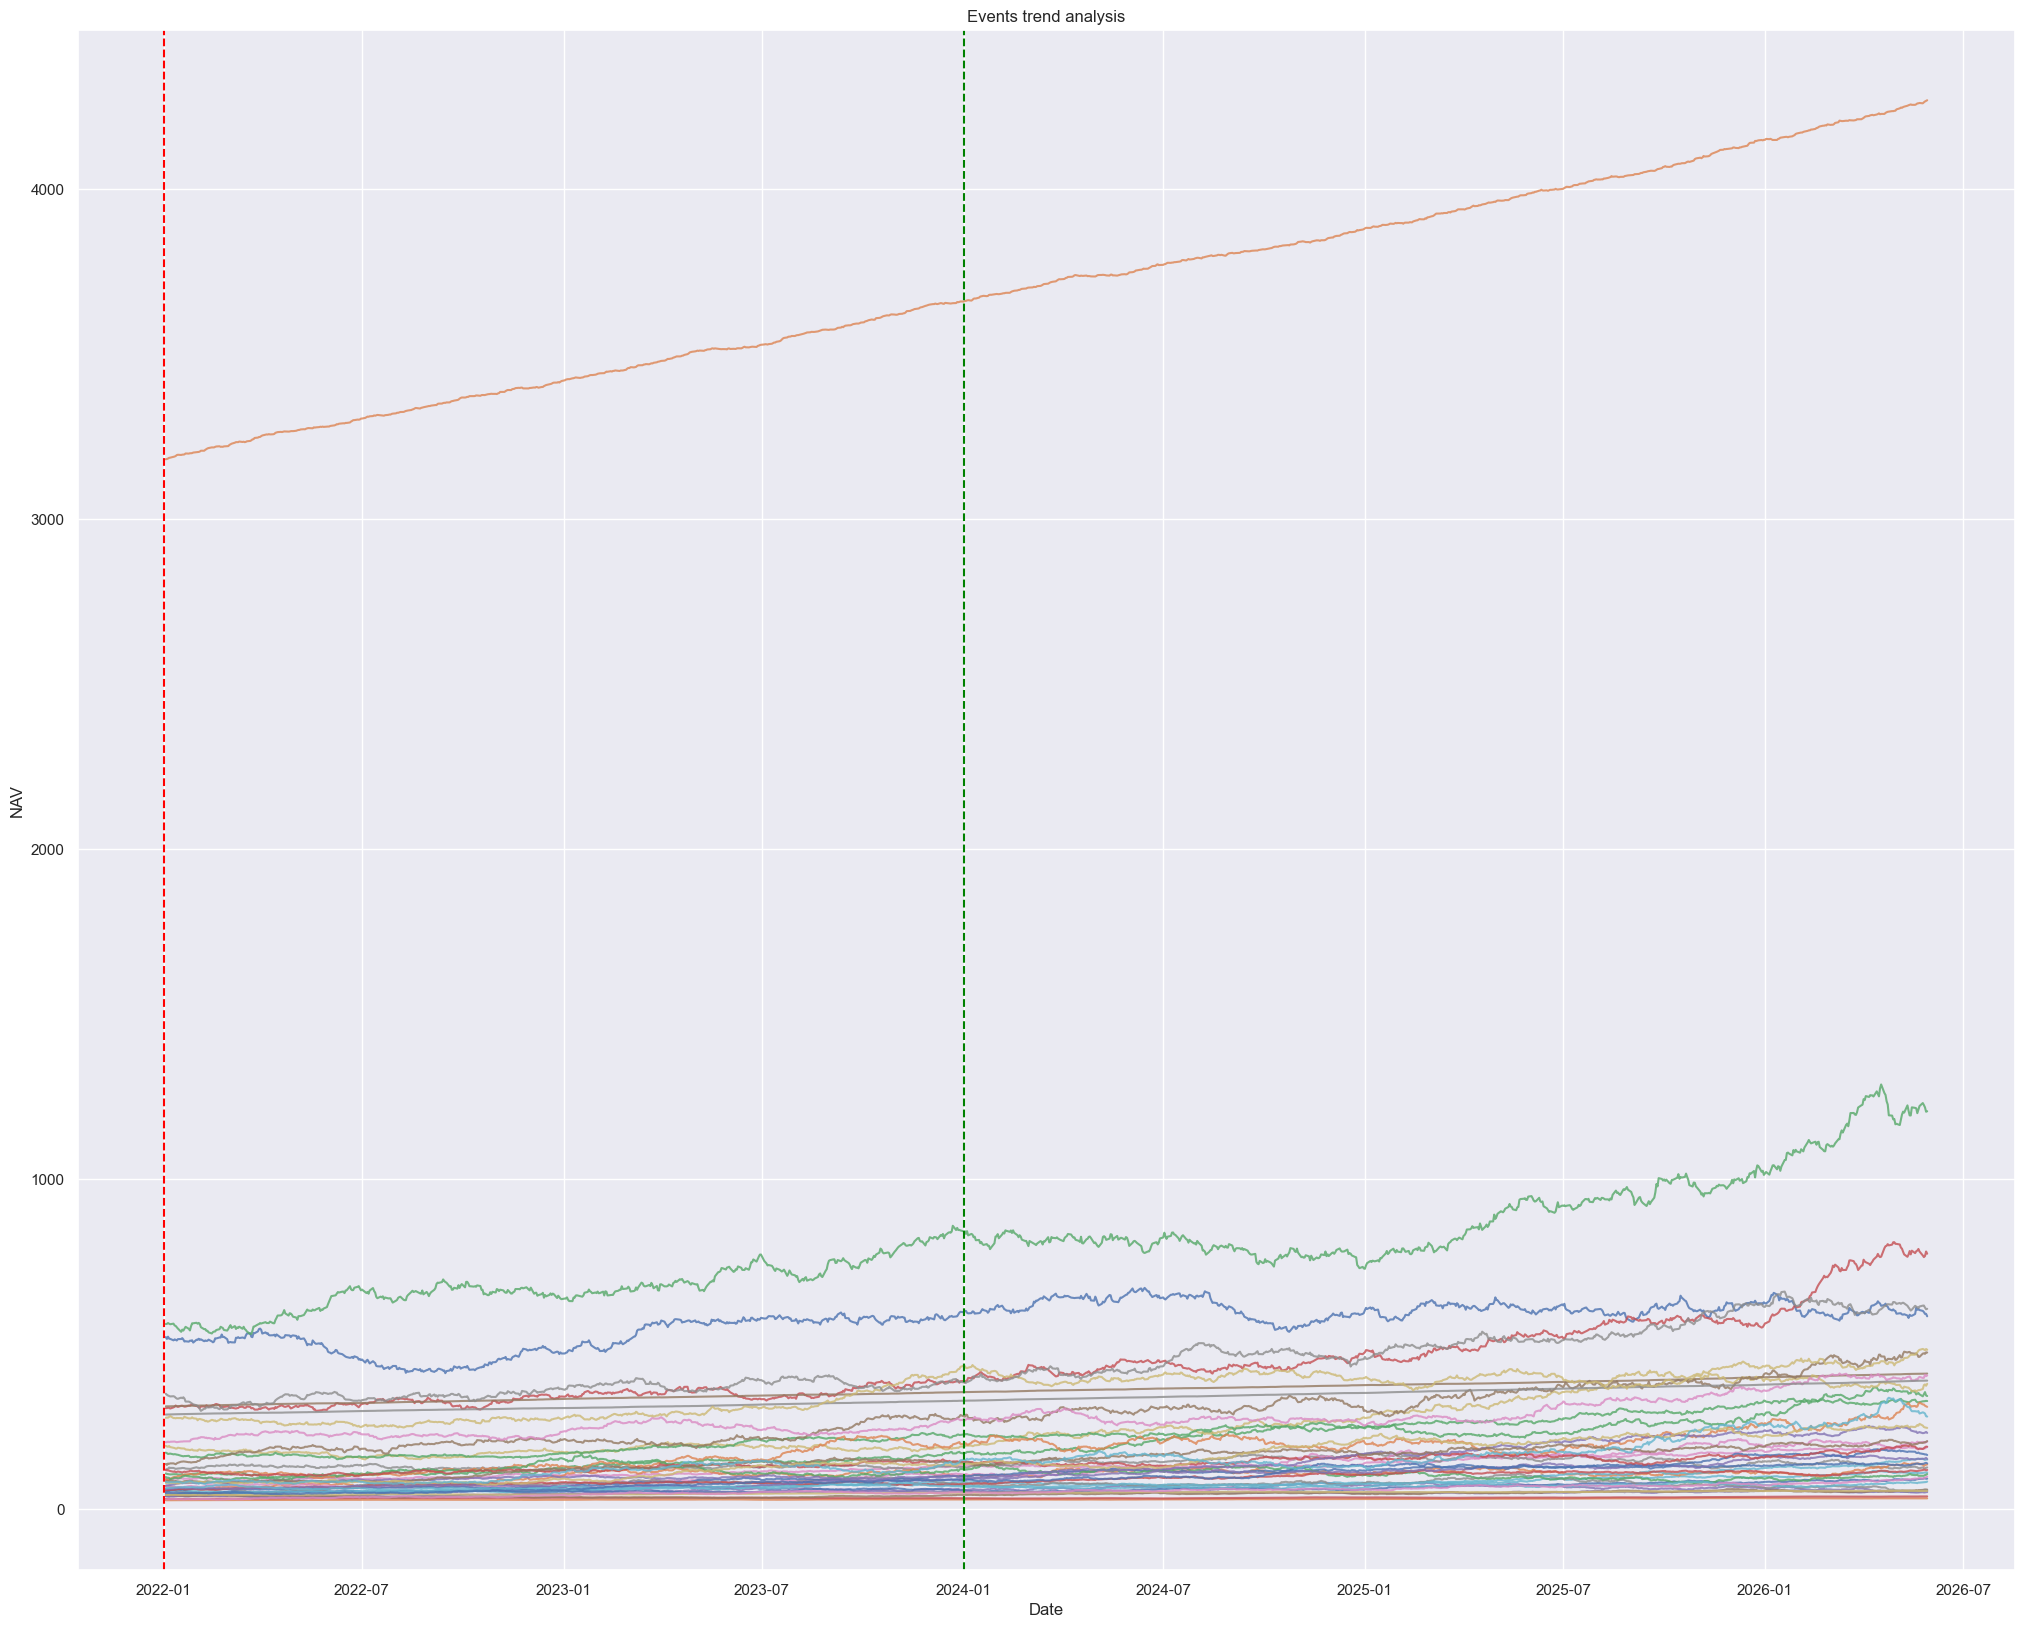

In [26]:
plt.figure(figsize = (25,20))
for scheme1 in code2:
    temp1 = nav_history[nav_history['amfi_code']==scheme1]
    plt.plot(
        temp1['date'],
        temp1['nav'],
        alpha = 0.8
        
    )
plt.axvline(pd.Timestamp('2022-01-01'), linestyle = '--', color = 'red', label = ' 2022 Covid recovery phase')
plt.axvline(pd.Timestamp('2023-01-01'), linestyle ='', color = 'blue' , label = '2023 Market Rally')
plt.axvline(pd.Timestamp('2024-01-01'), linestyle = '--', color = 'green', label= ' 2024 Correction ')
plt.title("Events trend analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.savefig("D:\\Bluestock\\mutual-fund-analytics\\reports\\NAV_trend_analysis.png", dpi=300, bbox_inches='tight')
plt.show()



In [27]:
aum_history.head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [29]:
aum_history['date']= pd.to_datetime(aum_history['date'], format = 'mixed')

In [30]:
aum_history.dtypes

date              datetime64[us]
fund_house                   str
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
dtype: object

In [35]:
aum = aum_history['fund_house'].unique()
aum

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

In [36]:
aum_history['year'] = aum_history['date'].dt.year

In [47]:
aum_yearly = (
    aum_history
    .sort_values('date')
    .groupby(['year','fund_house'])
    .last()
    .reset_index()
)

In [48]:
aum_yearly[
    aum_yearly['fund_house'] == 'SBI Mutual Fund'
][['year','aum_lakh_crore']]

,year,aum_lakh_crore
8,2022,6.30
18,2023,8.45
28,2024,11.14
38,2025,12.50


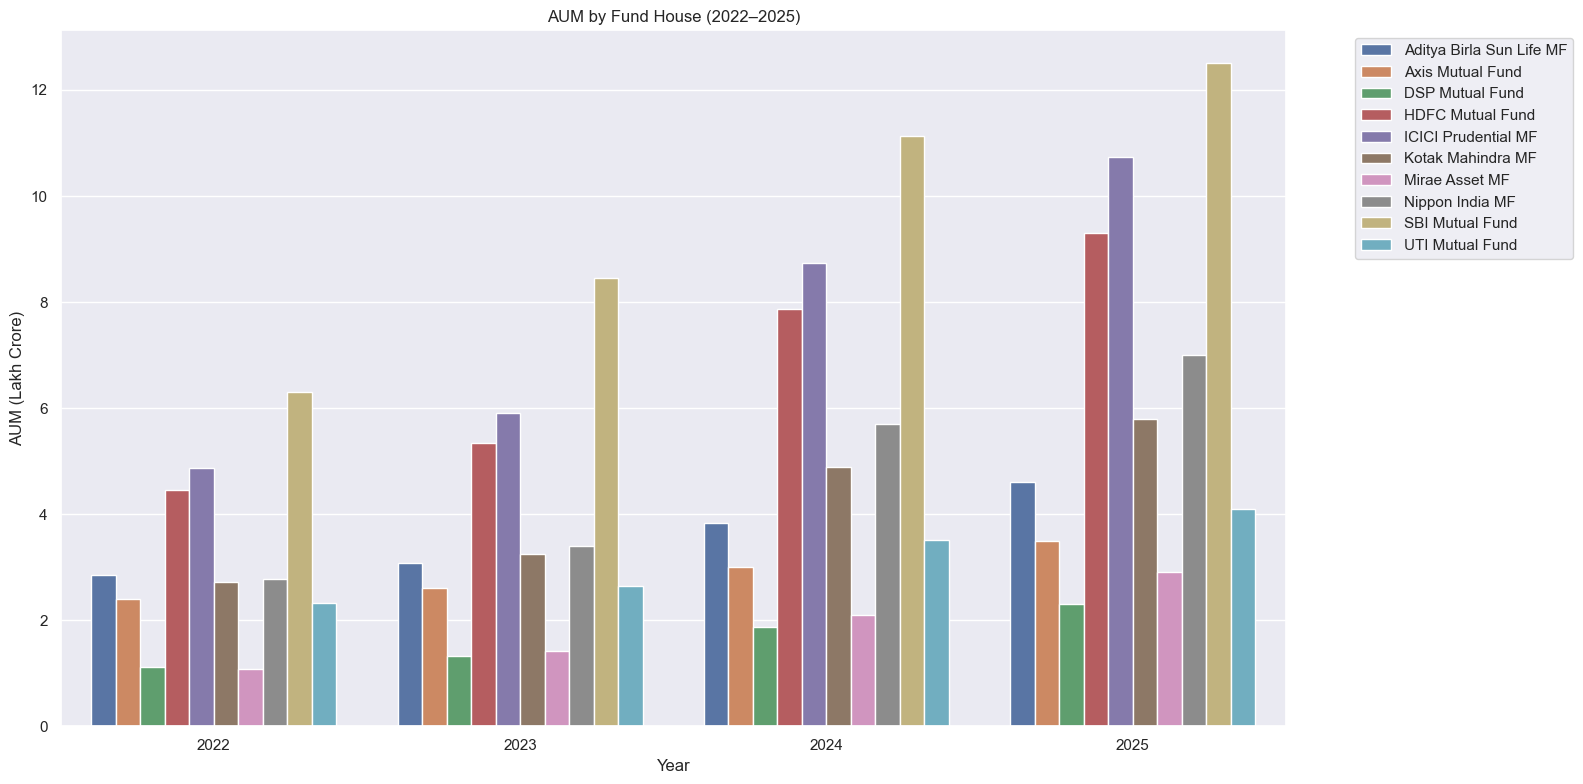

In [49]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## AUM Growth Analysis Findings

- SBI Mutual Fund maintained the highest AUM throughout the period.
- SBI reached approximately ₹12.5 lakh crore AUM by 2025.
- All major fund houses exhibited positive growth between 2022 and 2025.
- Industry assets expanded significantly during the study period.

In [53]:
monthly_sip_inflows.head(40)

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN
5,2022-06,12276,5.60,7.50,5.18,NaN
6,2022-07,12140,5.65,9.21,5.25,NaN
7,2022-08,12694,5.71,8.90,5.31,NaN
8,2022-09,12976,5.80,9.40,5.41,NaN
9,2022-10,13040,5.93,9.52,5.55,NaN


In [54]:
monthly_sip_inflows['sip_inflow_crore'].max()

np.int64(31002)

In [ ]:
monthly_sip_inflows['month'] = pd.to_datetime(
    monthly_sip_inflows['month']                           
) #convert string to datetime for better plotting 

In [58]:
peak_row = monthly_sip_inflows.loc[
    monthly_sip_inflows['sip_inflow_crore'].idxmax()
]

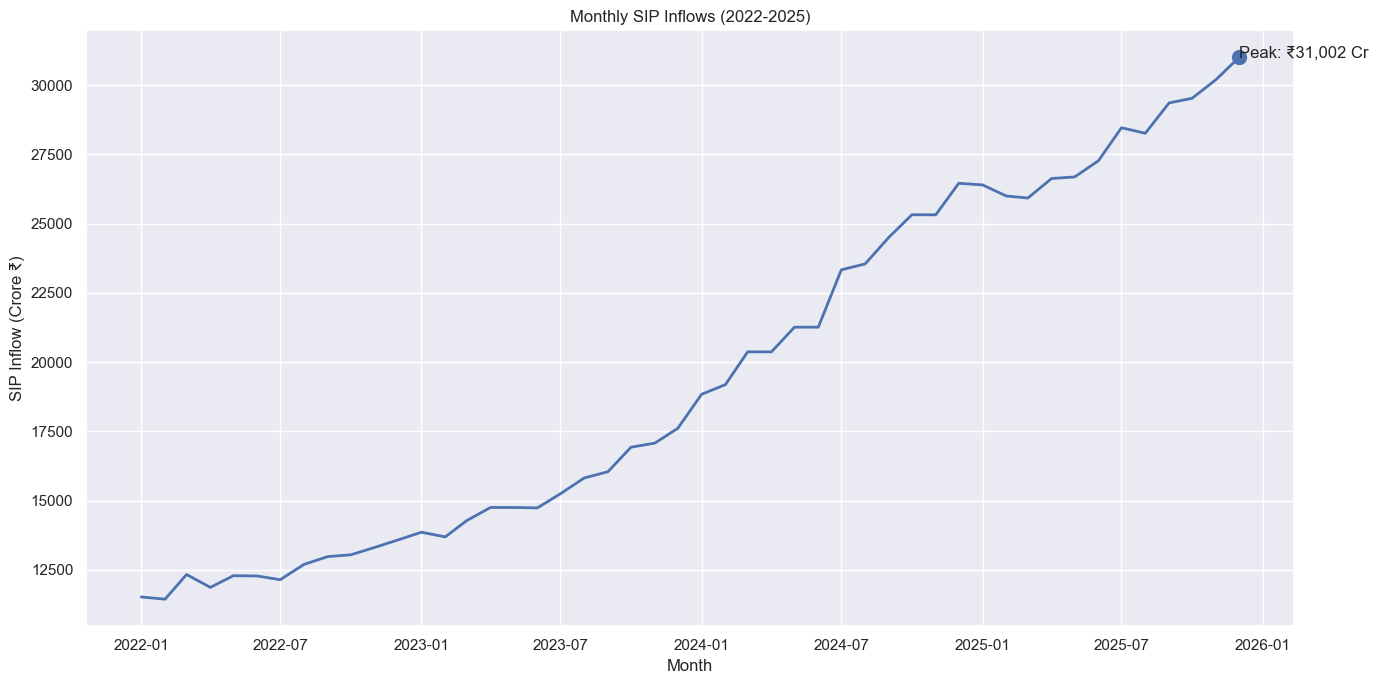

In [60]:
plt.figure(figsize=(14,7))

plt.plot(
    monthly_sip_inflows['month'],
    monthly_sip_inflows['sip_inflow_crore'],
    linewidth=2
)

plt.scatter(
    peak_row['month'],
    peak_row['sip_inflow_crore'],
    s=100
)

plt.annotate(
    f"Peak: ₹{peak_row['sip_inflow_crore']:,} Cr",
    (
        peak_row['month'],
        peak_row['sip_inflow_crore']
    )
)

plt.title("Monthly SIP Inflows (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/sip_inflow_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## SIP Inflow Analysis Findings

- SIP inflows increased steadily from 2022 to 2025.
- Monthly SIP inflows crossed ₹30,000 crore by the end of 2025.
- Investor participation increased consistently during the period.
- Active SIP accounts showed strong growth alongside inflows.
- SIP AUM expanded significantly, reflecting growing retail participation.

In [61]:
print(category_inflows.head(10),category_inflows.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB
     month           category  net_inflow_crore
0  2024-04          Large Cap            2413.0
1  2024-04            Mid Cap            3897.0
2  2024-04          Small Cap            3533.0
3  2024-04          Flexi Cap            4947.0
4  2024-04    Large & Mid Cap            4214.0
5  2024-04               ELSS             466.0
6  2024-04       Value/Contra            1328.0
7  2024-04  Sectoral/Thematic            8052.0
8  2024-04             Liquid           37537.0
9  2024-04     Short Duration            4400.0 None


In [62]:
category_inflows['month'] = pd.to_datetime(
    category_inflows['month']
)

In [63]:
heatmap_data = category_inflows.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

In [68]:
heatmap_data.columns = (
    pd.to_datetime(heatmap_data.columns)
    .strftime('%b-%Y')
)

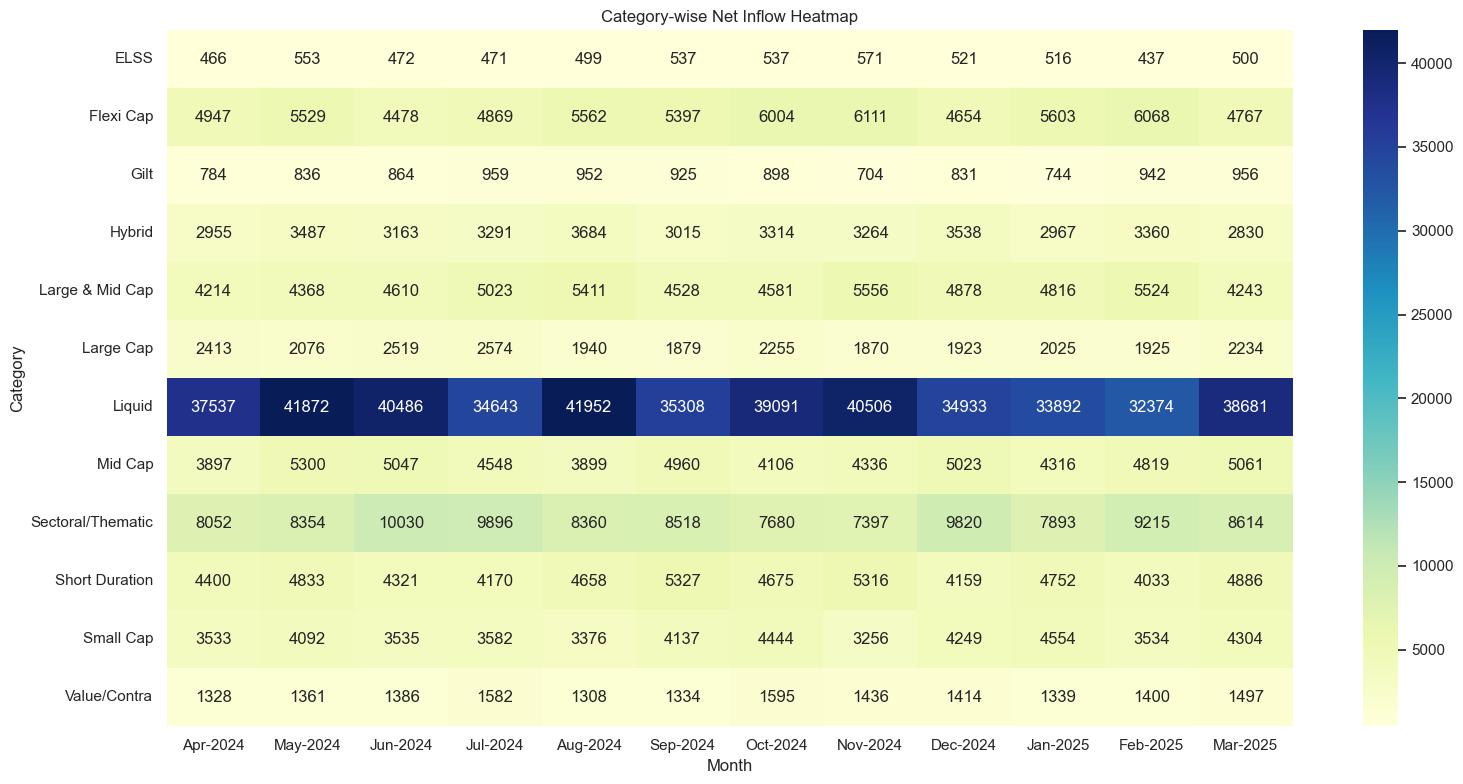

In [69]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/category_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Category Inflow Analysis Findings


- Liquid funds recorded the highest inflows across multiple months.
- Flexi Cap, Mid Cap and Small Cap funds consistently attracted investor interest.
- ELSS funds received comparatively lower inflows.
- Debt-oriented categories showed moderate inflow patterns.
- Investor preference was concentrated in growth-oriented equity categories.

In [70]:
# category_inflows.groupby(
#     ['category','month']
# ).size().value_counts()

In [73]:
age_dist = investor_transc['age_group'].value_counts(normalize=True) * 100

age_dist

age_group
26-35    41.073281
36-45    24.852035
18-25    14.997864
46-55    11.529074
56+       7.547745
Name: proportion, dtype: float64

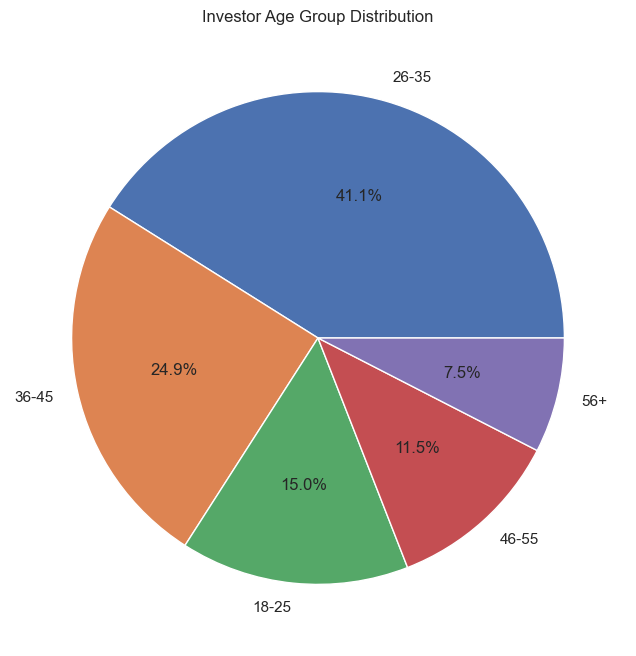

In [72]:
plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/age_group_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [75]:
sip_df = investor_transc[
    investor_transc['transaction_type'] == 'SIP'
]
sip_df

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32771,INV002074,2025-05-30,118633,SIP,2383,Karnataka,Bangalore,T30,26-35,Female,6.1,UPI,Verified
32772,INV000339,2025-05-30,148569,SIP,1109,Uttar Pradesh,Kanpur,B30,26-35,Male,22.3,Cheque,Verified
32774,INV001838,2025-05-30,119093,SIP,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified
32775,INV000074,2025-05-30,120504,SIP,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified


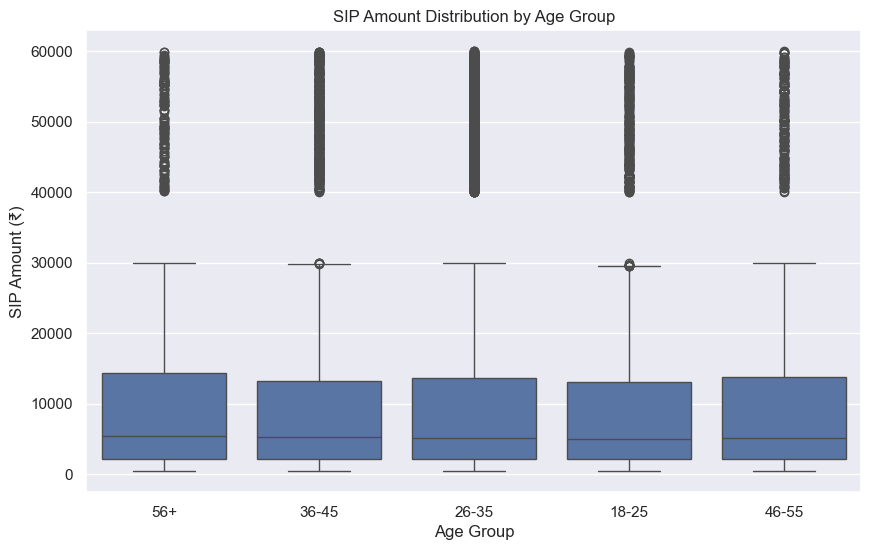

In [76]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/sip_boxplot_agegroup.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

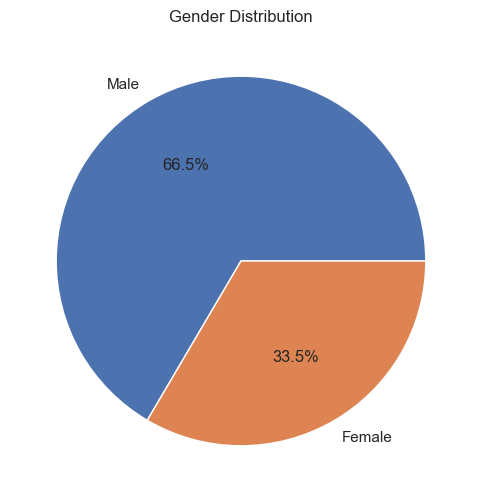

In [77]:
plt.figure(figsize=(6,6))

investor_transc['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/gender_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Investor Demographics Findings

- The 26–35 age group represents the largest share of investors.
- Younger investors (18–35) dominate mutual fund participation.
- SIP contribution patterns vary significantly across age groups.
- Higher age groups exhibit greater variation in SIP amounts.
- Retail participation is concentrated among working-age investors.

In [78]:
sip_df = investor_transc[
    investor_transc['transaction_type'] == 'SIP'
]

In [79]:
state_sip = (
    sip_df
    .groupby('state')['amount_inr']
    .sum()
    .sort_values()
)

state_sip.head()

state
Maharashtra      16445629
Rajasthan        16544233
Delhi            17113608
West Bengal      17495769
Uttar Pradesh    17534858
Name: amount_inr, dtype: int64

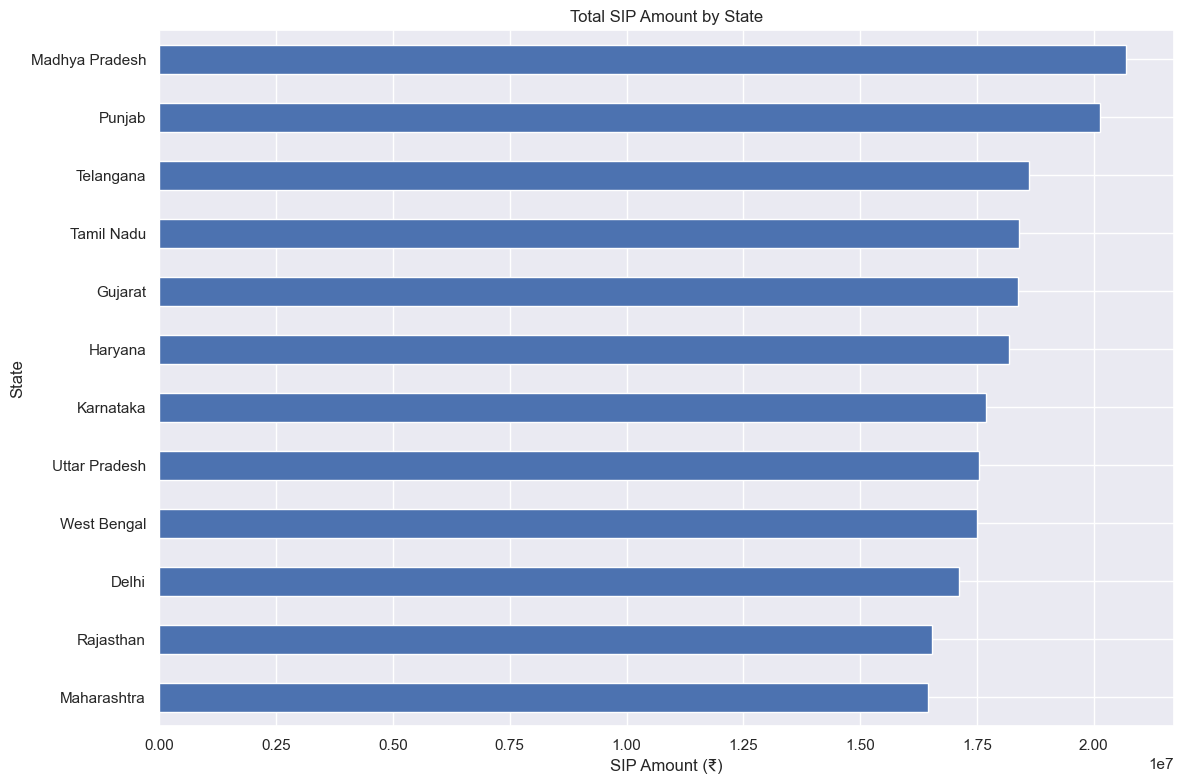

In [80]:
plt.figure(figsize=(12,8))

state_sip.plot(
    kind='barh'
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/sip_by_state.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [81]:
investor_transc['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

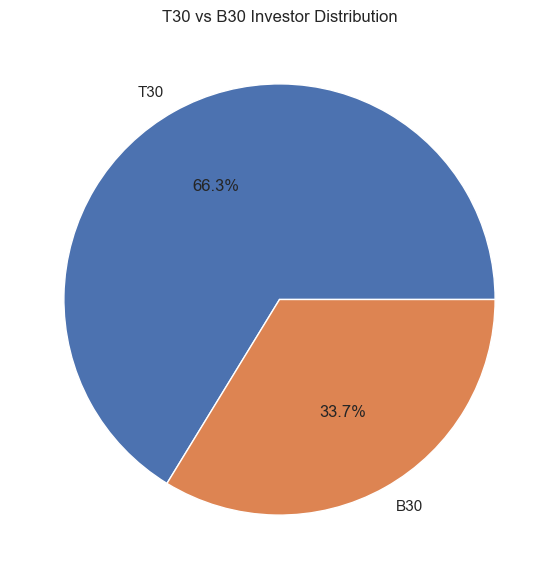

In [82]:
city_tier_dist = (
    investor_transc['city_tier']
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_dist,
    labels=city_tier_dist.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/t30_vs_b30.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

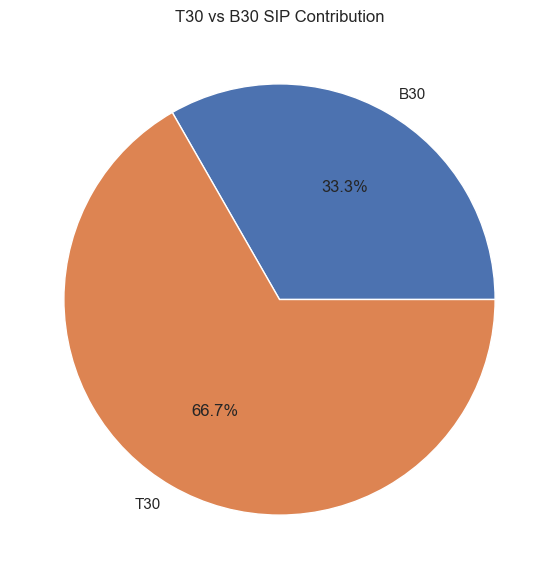

In [83]:
tier_sip = (
    sip_df
    .groupby('city_tier')['amount_inr']
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    tier_sip,
    labels=tier_sip.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 SIP Contribution")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/t30_vs_b30_sip.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Geographic Distribution Findings

- T30 cities account for the majority of mutual fund investments.
- B30 cities continue to contribute a meaningful share of SIP inflows.
- Mutual fund penetration is strongest in major metropolitan regions.
- Several states contribute disproportionately to overall SIP investments.
- Geographic diversification of investors is increasing beyond T30 locations.

In [84]:
print(industry_folio_counts.dtypes)
industry_folio_counts['month'] = pd.to_datetime(
    industry_folio_counts['month']
)

month                      str
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_folios_crore    float64
others_folios_crore    float64
dtype: object


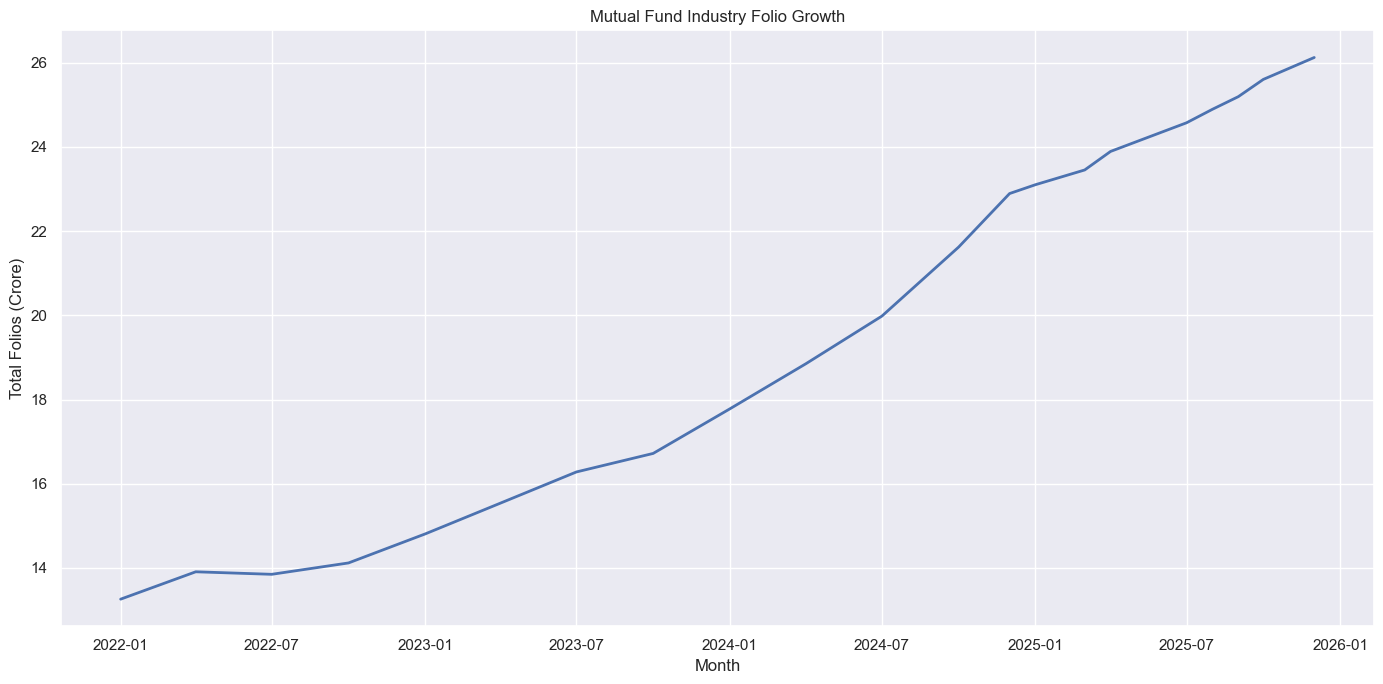

In [85]:
plt.figure(figsize=(14,7))

plt.plot(
    industry_folio_counts['month'],
    industry_folio_counts['total_folios_crore'],
    linewidth=2
)

plt.title("Mutual Fund Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/folio_growth.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Folio Growth Findings

- Total folio count nearly doubled during the analysis period.
- Equity folios contributed the largest share of industry growth.
- Retail participation increased steadily across all categories.
- Industry folios reached record highs by the end of 2025.
- Growth reflects increasing investor awareness and participation.

In [86]:
nav_history

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [87]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [88]:
nav_pivot = nav_history.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [89]:
nav_pivot

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-25,599.9335,31.9938,341.0618,767.9581,54.3271,409.3925,181.9025,125.4990,363.3097,108.9319,...,166.6261,4259.2727,1229.7696,181.5499,229.4356,199.7098,91.4336,615.8714,252.3926,292.4810
2026-05-26,596.4426,31.9646,347.6301,762.9328,53.4341,409.4504,182.9999,122.9135,375.0758,109.7152,...,166.0096,4262.3302,1223.5953,183.6132,229.9402,201.0499,93.3272,616.0989,248.0480,291.2707
2026-05-27,590.8555,31.9203,353.8026,766.2056,53.7534,409.7188,183.3905,123.1859,377.1098,110.2646,...,164.8981,4264.9256,1216.6203,186.8384,231.1083,202.3780,94.5121,609.8571,246.8691,288.8007


In [90]:
nav_pivot = nav_pivot.iloc[:, :10]

In [91]:
returns = nav_pivot.pct_change()

In [92]:
corr_matrix = returns.corr()

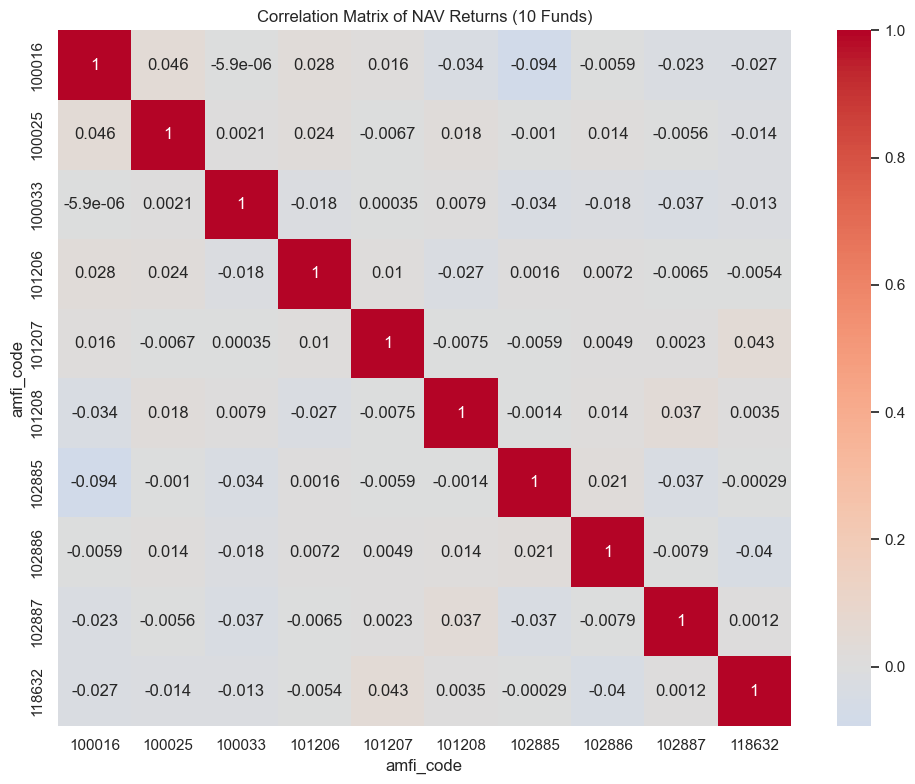

In [93]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of NAV Returns (10 Funds)")

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/correlation_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Correlation Analysis Findings

- Most equity-oriented funds exhibit strong positive correlations.
- Several funds move together due to common market exposure.
- Correlation coefficients are generally high, indicating broad market influence.
- Diversification benefits are reduced among highly correlated funds.
- Certain funds show relatively lower correlation, offering diversification opportunities.

In [94]:
portfolio_holdings

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31
...,...,...,...,...,...,...,...,...
317,149324,DIVISLAB,Divi's Laboratories,Pharma,9.54,855.88,7453.05,2025-12-31
318,149324,BHARTIARTL,Bharti Airtel Ltd,Telecom,1.79,969.71,924.41,2025-12-31
319,149324,TCS,Tata Consultancy Services,IT,13.17,1637.69,1927.89,2025-12-31
320,149324,INDUSINDBK,IndusInd Bank Ltd,Banking,7.63,1387.30,3208.86,2025-12-31


In [95]:
sector_weights = (
    portfolio_holdings
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [96]:
sector_weights.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

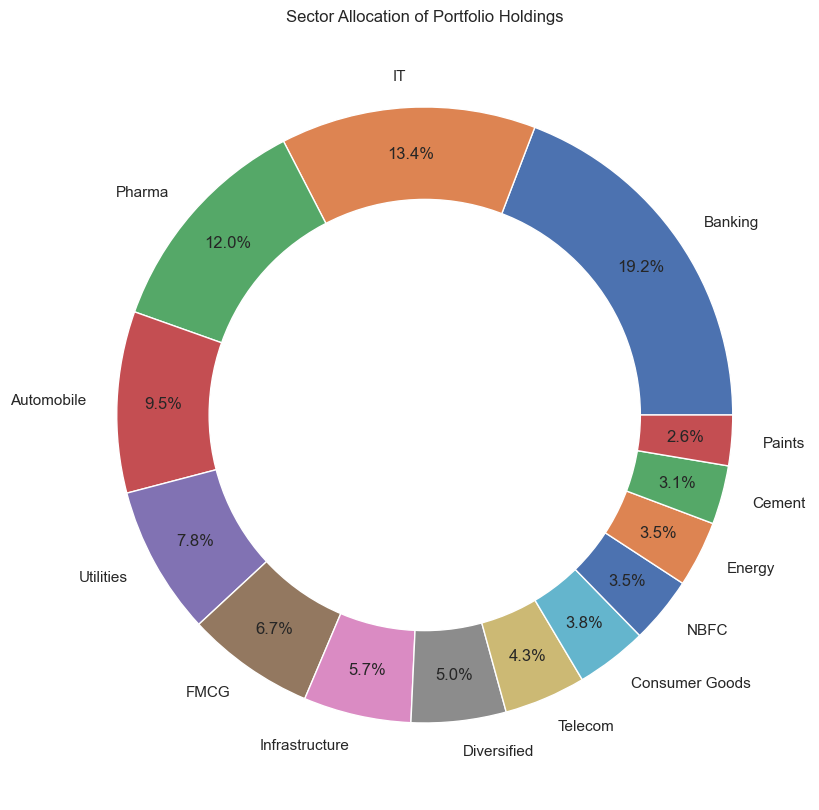

In [97]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    pctdistance=0.85
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation of Portfolio Holdings")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Sector Allocation Findings

- Banking is the largest sector allocation in the portfolio holdings.
- Technology and Consumer-related sectors also hold significant weights.
- Portfolio exposure is diversified across multiple sectors.
- Banking stocks remain the preferred allocation among large-cap mutual funds.
- Sector diversification helps reduce concentration risk.

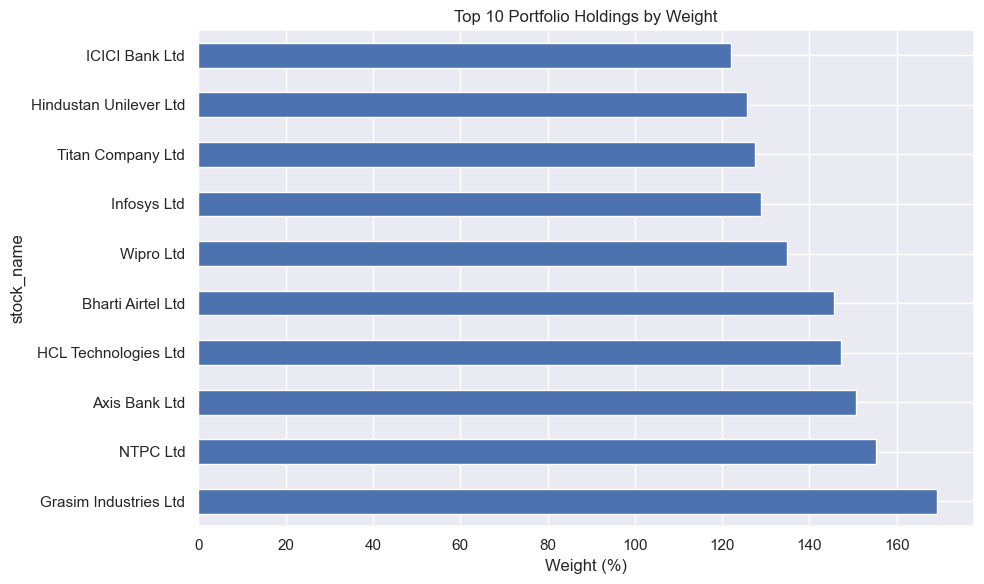

In [98]:
top_stocks = (
    portfolio_holdings
    .groupby('stock_name')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_stocks.plot(kind='barh')

plt.title("Top 10 Portfolio Holdings by Weight")
plt.xlabel("Weight (%)")

plt.tight_layout()

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/top_10_holdings.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

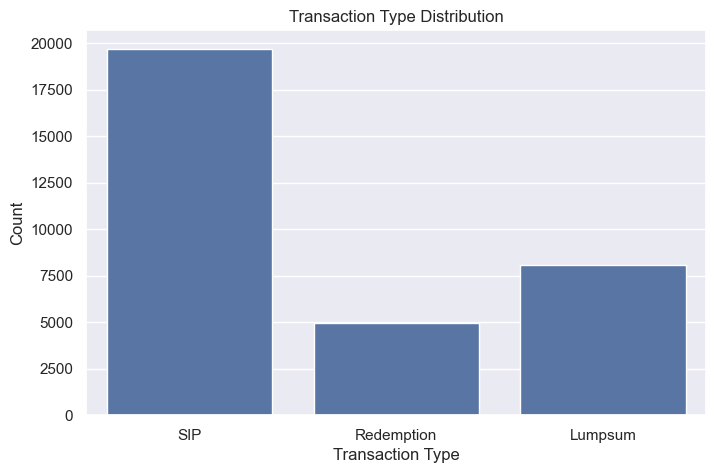

In [99]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor_transc,
    x='transaction_type'
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/transaction_type_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

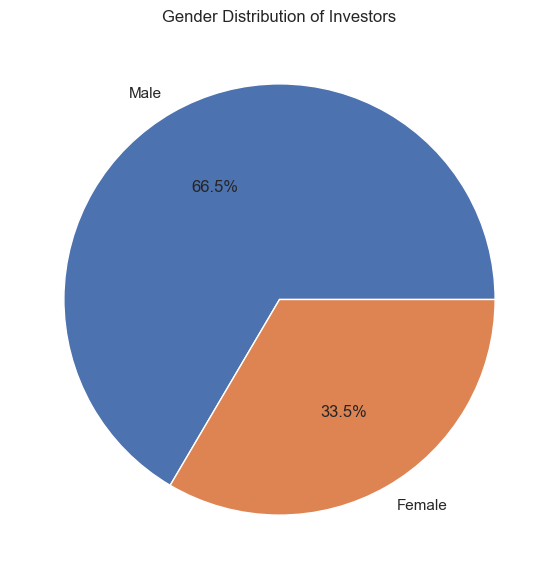

In [100]:
plt.figure(figsize=(7,7))

investor_transc['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "D:/Bluestock/mutual-fund-analytics/reports/gender_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Executive Summary

## Key Findings

1. NAV values showed consistent long-term growth across all 40 schemes.
2. SBI Mutual Fund emerged as the AUM leader with approximately ₹12.5 lakh crore.
3. Monthly SIP inflows reached record highs by the end of 2025.
4. Equity-oriented categories attracted the highest investor inflows.
5. The 26–35 age group represented the largest investor segment.
6. T30 cities contributed the majority of investments.
7. Mutual fund folio counts nearly doubled during the analysis period.
8. Most funds exhibited strong positive return correlations.
9. Banking was the largest sector allocation across portfolio holdings.
10. Retail participation in mutual funds continued to grow steadily.